# Evaluting timing of the WEP pipeline on USDF

Owner: Bryce Kalmbach ([@jbkalmbach)](https://github.com/lsst-ts/ts_aos_analysis/issues/new?body=@jbkalmbach)

Last Verified to Run: 2024-08-22

Software Versions:
* `lsst_distrib`: **w_2024_32**

Requirements:
* `lsst_distrib`
* `ts_aos_analysis`

## Notebook Objective
This notebook calculates the timing to run the AOS Wavefront Estimation Pipeline (WEP).
We evaluate the timing based upon the information stored in the butler metadata as each task runs.

## Logistics
This notebook as written can be run on USDF using the AOS butler at `/sdf/data/rubin/repo/aos_imsim/`. 
You will need to change the repo directory if you want to access the timing of the pipeline in other USDF repos or on the summit. 
To do so change the `butler_path` and `collection_name` variables below accordingly.

## Imports

In [1]:
import numpy as np
from lsst.daf.butler import Butler
from astropy.time import Time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

In [2]:
from lsst.ts.aos.analysis import get_task_metadata, get_timing_from_metadata

In [3]:
from lsst.daf.butler import DatasetNotFoundError

In [4]:
import pickle

## Load Test Data

In [59]:
butler_path = '/sdf/group/rubin/repo/aos_imsim'
collection_name = 'u/brycek/updated_timing_test_cwfs_tie'
instrument = 'LSSTCam'

Specify the exposures and detector IDs in the list below based upon the data and instrument upon which the pipeline ran.

In [60]:
butler = Butler(butler_path)
butler_records = butler.query_dimension_records('exposure')#, where="exposure.day_obs = 20241211 and instrument='LSSTComCam' and exposure.observation_type = 'cwfs' and exposure.seq_num < 463")

In [61]:
group_exp_dict = dict()
for rec in butler_records:
    if rec.group in group_exp_dict.keys():
        group_exp_dict[rec.group].append(rec.id)
    else:
        group_exp_dict[rec.group] = [rec.id]

In [62]:
group_exp_dict_sorted = dict(sorted(group_exp_dict.items()))

In [63]:
group_exp_dict_sorted

{'1': [7024072305113,
  7024072305019,
  7024072305007,
  7024072305013,
  7024072305001,
  7024072305025,
  7024072305101,
  7024072305107],
 '10': [7024072305122,
  7024072305052,
  7024072305046,
  7024072305034,
  7024072305040,
  7024072305058,
  7024072305128,
  7024072305134],
 '11': [7024072305059,
  7024072305047,
  7024072305035,
  7024072305053,
  7024072305041,
  7024072305123,
  7024072305129,
  7024072305135],
 '12': [7024072305048,
  7024072305054,
  7024072305036,
  7024072305060,
  7024072305042,
  7024072305130,
  7024072305124,
  7024072305136],
 '13': [7024072305079,
  7024072305067,
  7024072305073,
  7024072305085,
  7024072305061,
  7024072305143,
  7024072305137,
  7024072305149],
 '14': [7024072305062,
  7024072305068,
  7024072305080,
  7024072305086,
  7024072305074,
  7024072305144,
  7024072305138,
  7024072305150],
 '15': [7024072305075,
  7024072305081,
  7024072305063,
  7024072305069,
  7024072305087,
  7024072305139,
  7024072305145,
  7024072305151],


In [64]:

# exposure_list = [2024120800553, 2024120800554]
detector_list = [191, 192, 195, 196, 199, 200, 203, 204] # ComCam Detectors
# group_list = [butler.get(
#     'postISRCCD.metadata', 
#     dataId={'instrument': 'LSSTComCam', 'detector': 0, 'exposure': exp},
#     collections='LSSTComCam/quickLook'
# )['GROUPID'] for exp in exposure_list]

In [65]:
# If you ran the pipeline with additional aggregate and plotting tasks uncomment required tasks
task_list = [
    "isr",
    "generateDonutDirectDetectTask",
    # "aggregateDonutCatalogsTask",
    "cutOutDonutsCwfsTask",
    # "aggregateDonutStampsTask",
    # "plotDonutTask",
    'reassignCwfsCutoutsTask',
    "calcZernikesTask",
    # "aggregateZernikesTask",
    # "aggregateAOSVisitTableTask",
    # "plotAOSTask",
]

In [66]:
# If you ran the pipeline with additional aggregate and plotting tasks uncomment required tasks
colors = {
    'isr': 'k',
    'generateDonutDirectDetectTask': 'r',
    # 'aggregateDonutCatalogsTask': 'g',
    'cutOutDonutsScienceSensorGroupTask': 'b',
    # 'aggregateDonutStampsTask': 'c',
    # 'plotDonutTask': 'm',
    'reassignCwfsCutoutsTask' : 'green',
    'calcZernikesTask': 'y',
    # 'aggregateZernikesTask': 'orange',
    # 'aggregateAOSVisitTableTask': 'gray',
    # 'plotAOSTask': 'pink'
}

In [67]:
# CWFS Version
full_timing_dict = dict()
for task in task_list:
    full_timing_dict[task] = []
for group, exposure_list in [['5024072302001', [5024072302001]]]:
    group_list = [group]
    try:
        print(group_list, detector_list, exposure_list)
        task_metadata = get_task_metadata(butler_path, collection_name, instrument, task_list, exposure_list, group_list, detector_list)
        print(task_metadata)
        jobs, first_job, last_job, longest_job_5_donuts = get_timing_from_metadata(task_metadata)
    except:
        print(group)
        continue
    for job in jobs:
        timing = (((Time(job[2][:-6]).mjd)) - ((Time(job[1][:-6]).mjd))) * 86400
        if timing <= 0:
            continue
        else:
            full_timing_dict[job[0]].append(timing)

['5024072302001'] [191, 192, 195, 196, 199, 200, 203, 204] [5024072302001]
5024072302001 5024072302001 191 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 192 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 195 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 196 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 199 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 200 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 203 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 204 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 191 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 192 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 195 LSSTCam u/brycek/updated_timing_test_cwfs_tie
5024072302001 5024072302001 196 LSSTCam u/brycek/updated_timing_tes

In [68]:
full_timing_dict

{'isr': [np.float64(3.832621034234762),
  np.float64(3.957769344560802),
  np.float64(4.0906650479882956),
  np.float64(3.741754498332739),
  np.float64(3.6686012288555503),
  np.float64(5.862602102570236),
  np.float64(3.554490627720952),
  np.float64(3.4457737812772393)],
 'generateDonutDirectDetectTask': [np.float64(1.924711070023477),
  np.float64(1.9059643149375916),
  np.float64(1.8477262230589986),
  np.float64(2.1843442926183343),
  np.float64(1.9249769859015942),
  np.float64(1.9080149475485086),
  np.float64(2.0149194169789553),
  np.float64(2.365441806614399)],
 'cutOutDonutsCwfsTask': [np.float64(2.1647589281201363),
  np.float64(1.937811984680593),
  np.float64(2.371168741956353),
  np.float64(1.9266240298748016),
  np.float64(2.215680875815451),
  np.float64(2.018256881274283),
  np.float64(1.9242961658164859),
  np.float64(1.7867189599201083)],
 'reassignCwfsCutoutsTask': [np.float64(2.355289226397872),
  np.float64(2.355289226397872),
  np.float64(2.355289226397872),
  

In [16]:
full_timing_dict = dict()
for task in task_list:
    full_timing_dict[task] = []
for group, exposure_list in group_exp_dict_sorted.items():
    group_list = [group] * 2
    try:
        task_metadata = get_task_metadata(butler_path, collection_name, instrument, task_list, exposure_list, group_list, detector_list)
        jobs, first_job, last_job, longest_job_5_donuts = get_timing_from_metadata(task_metadata)
    except:
        print(group)
        continue
    for job in jobs:
        timing = (((Time(job[2][:-6]).mjd)) - ((Time(job[1][:-6]).mjd))) * 86400
        if timing <= 0:
            continue
        else:
            full_timing_dict[job[0]].append(timing)

1
10
11
12
13
14
15
16
17
18
2
3
4
5
5024072300001
5024072300002
5024072300003
5024072300004
5024072300005
5024072300006
5024072300007
5024072300008
5024072300009
5024072300010
5024072300011
5024072300012
5024072300013
5024072300014
5024072300015
5024072300016
5024072300017
5024072300018
5024072300019
5024072300020
5024072300021
5024072300022
5024072300023
5024072300024
5024072300025
5024072300026
5024072300027
5024072300028
5024072300029
5024072300030
5024072300031
5024072300032
5024072300033
5024072300034
5024072300035
5024072300036
5024072300037
5024072300038
5024072300039
5024072300040
5024072300041
5024072300042
5024072300043
5024072300044
5024072300045
5024072300046
5024072300047
5024072300048
5024072300049
5024072300050
5024072300051
5024072300052
5024072300053
5024072300054
5024072300055
5024072300056
5024072300057
5024072300058
5024072300059
5024072300060
5024072300061
5024072300062
5024072300063
5024072300064
5024072300065
5024072300066
5024072300067
5024072300068
50240723000

In [20]:
group

'9'

In [17]:
# with open('comcam_onsky_timing.pickle', 'rb') as f:
#     full_timing_dict = pickle.load(f)

(0.0, 10.0)

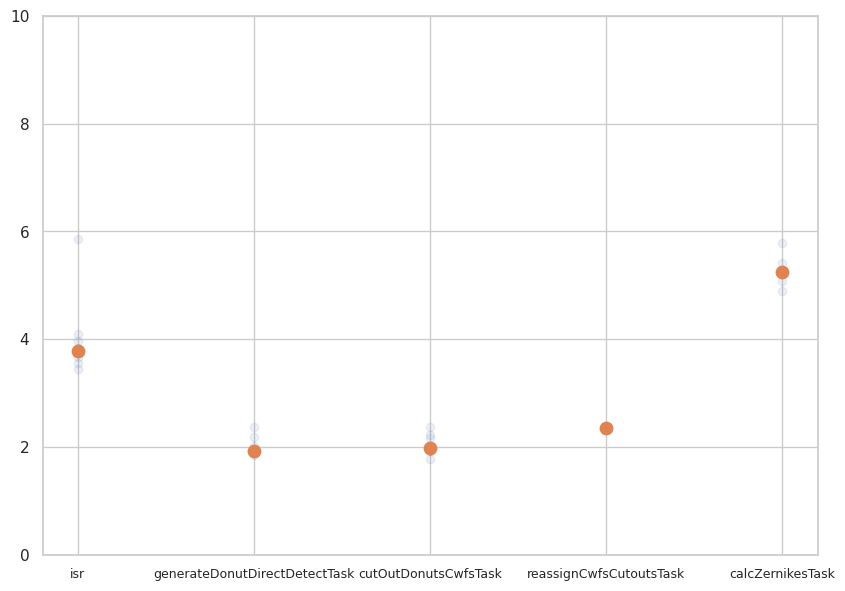

In [69]:
fig = plt.figure(figsize=(10, 7))
for i, task in enumerate(task_list):
    plt.scatter([i]*len(full_timing_dict[task]), full_timing_dict[task], alpha=0.1, c='C0')
    plt.scatter(i, np.median(full_timing_dict[task]), c='C1', s=80)
#    plt.errorbar(i, np.median(full_timing_dict[task]), yerr=np.std(full_timing_dict[task]), c='C1')
plt.xticks([0, 1, 2, 3, 4], task_list, fontsize=9)
plt.ylim(0, 10)

In [71]:
import seaborn as sbs
import pandas as pd

In [72]:
df = pd.DataFrame([], columns=['task_name', 'time'])
for task in task_list:
    df = pd.concat([df, pd.DataFrame(np.array([[task]*len(full_timing_dict[task]), np.array(full_timing_dict[task], dtype=float)]).T, columns=['task_name', 'time'])])

In [73]:
print(df)

                       task_name                time
0                            isr   3.832621034234762
1                            isr   3.957769344560802
2                            isr  4.0906650479882956
3                            isr   3.741754498332739
4                            isr  3.6686012288555503
5                            isr   5.862602102570236
6                            isr   3.554490627720952
7                            isr  3.4457737812772393
0  generateDonutDirectDetectTask   1.924711070023477
1  generateDonutDirectDetectTask  1.9059643149375916
2  generateDonutDirectDetectTask  1.8477262230589986
3  generateDonutDirectDetectTask  2.1843442926183343
4  generateDonutDirectDetectTask  1.9249769859015942
5  generateDonutDirectDetectTask  1.9080149475485086
6  generateDonutDirectDetectTask  2.0149194169789553
7  generateDonutDirectDetectTask   2.365441806614399
0           cutOutDonutsCwfsTask  2.1647589281201363
1           cutOutDonutsCwfsTask   1.937811984

In [74]:
df['time'] = pd.to_numeric(df['time'])
print(df['time'])

0    3.832621
1    3.957769
2    4.090665
3    3.741754
4    3.668601
5    5.862602
6    3.554491
7    3.445774
0    1.924711
1    1.905964
2    1.847726
3    2.184344
4    1.924977
5    1.908015
6    2.014919
7    2.365442
0    2.164759
1    1.937812
2    2.371169
3    1.926624
4    2.215681
5    2.018257
6    1.924296
7    1.786719
0    2.355289
1    2.355289
2    2.355289
3    2.355289
4    2.355289
5    2.355289
6    2.355289
7    2.355289
0    5.411082
1    4.898647
2    5.776308
3    5.088677
Name: time, dtype: float64


In [75]:
print(pd.DataFrame({
     'task_name': ['isr'] * 5 + ['calcZernikesTask'] * 5,
     'time': [14.71, 14.55, 15.53, 14.55, 14.39, 8.34, 5.55, 7.34, 6.37, 6.98]
}))

          task_name   time
0               isr  14.71
1               isr  14.55
2               isr  15.53
3               isr  14.55
4               isr  14.39
5  calcZernikesTask   8.34
6  calcZernikesTask   5.55
7  calcZernikesTask   7.34
8  calcZernikesTask   6.37
9  calcZernikesTask   6.98


ValueError: num must be an integer with 1 <= num <= 4, not 5

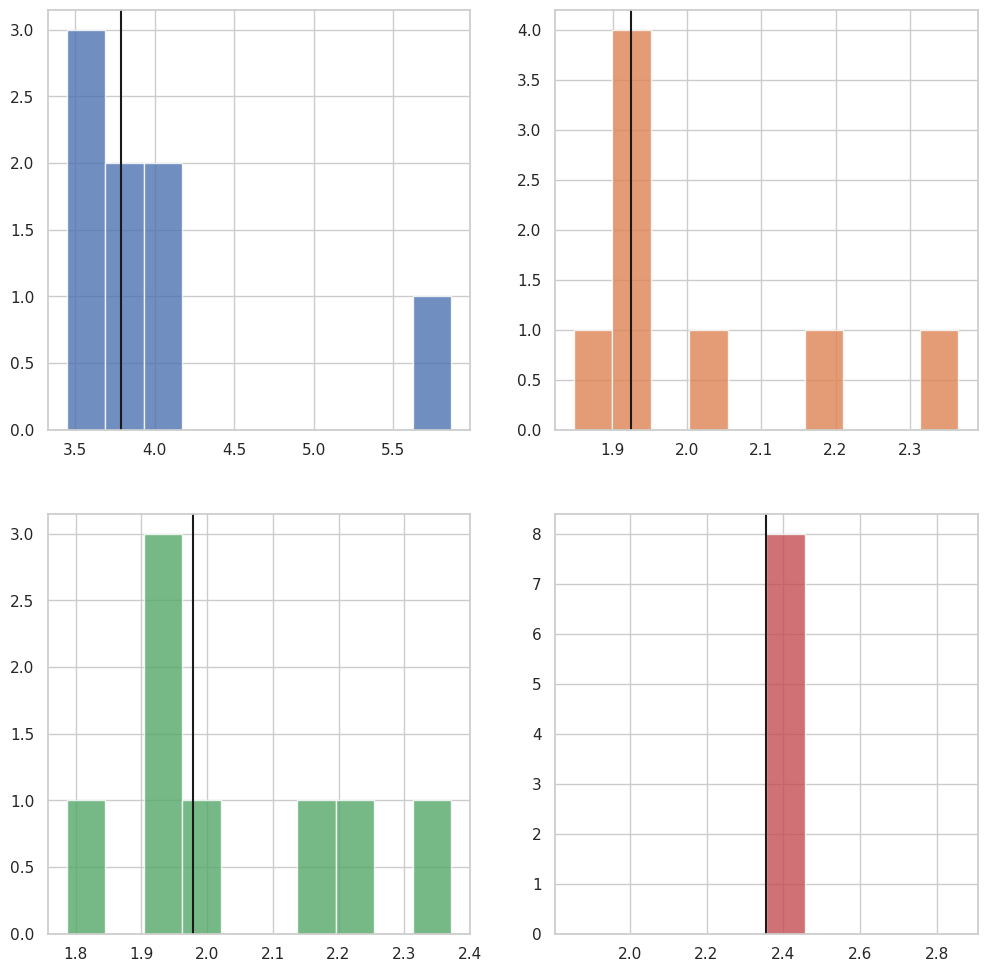

In [76]:
fig = plt.figure(figsize=(12, 12))
for i, task in enumerate(task_list):
    fig.add_subplot(2,2,i+1)
    plt.hist(full_timing_dict[task], alpha=0.8, color=f'C{i}')
    plt.axvline(np.median(full_timing_dict[task]), c='k')


/tmp/ipykernel_6476/177635727.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x="time", hue="task_name")


<Axes: xlabel='time', ylabel='Density'>

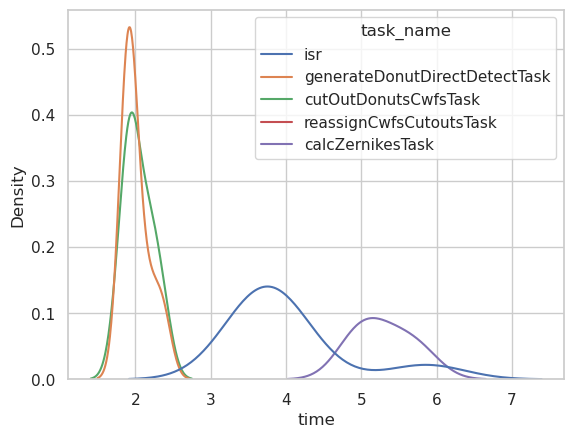

In [77]:
fig = plt.figure()
sns.kdeplot(data=df, x="time", hue="task_name")

task_name
calcZernikesTask                 5.249879
cutOutDonutsCwfsTask             1.978034
generateDonutDirectDetectTask    1.924844
isr                              3.787188
reassignCwfsCutoutsTask          2.355289
Name: time, dtype: float64


/tmp/ipykernel_6476/3888265827.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='task_name', y='time', data=df, showfliers=False, palette="muted")


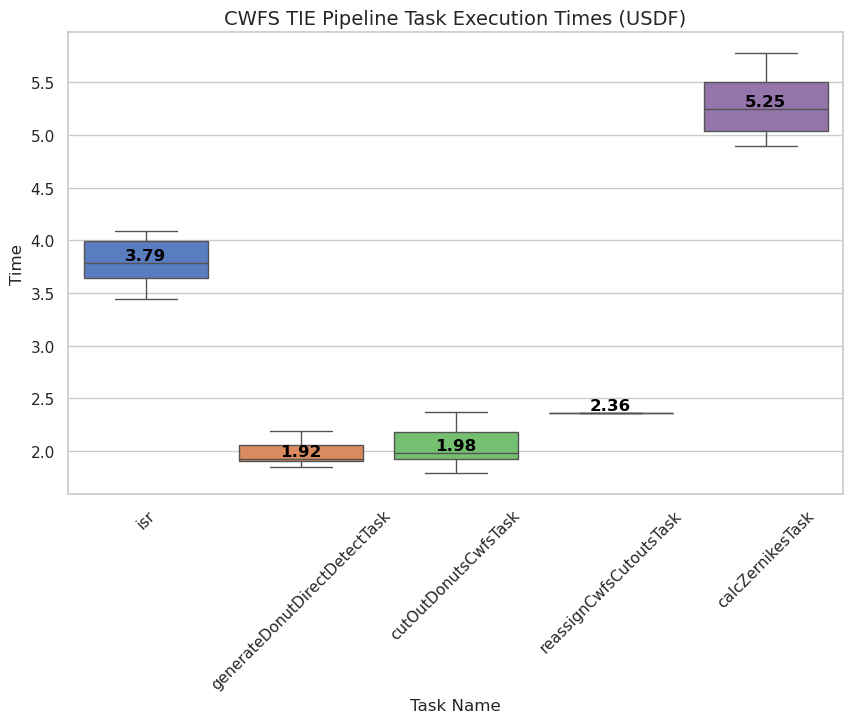

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#Sample data (replace with your actual DataFrame)
# df = pd.DataFrame({
#     'task_name': ['isr'] * 50 + ['calcZernikesTask'] * 50,
#     'time': [14.71, 14.55, 15.53, 14.55, 14.39, 8.34, 5.55, 7.34, 6.37, 6.98]*10
# })

# Set the plot style
sns.set(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='task_name', y='time', data=df, showfliers=False, palette="muted")

# Customize labels and title
plt.xlabel('Task Name', fontsize=12)
plt.ylabel('Time', fontsize=12)
plt.title('CWFS Danish Pipeline Task Execution Times (USDF)', fontsize=14)
# ax.yaxis.grid(False)
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

# Calculate medians for each task
medians = df.groupby('task_name')['time'].median()
print(medians)
for i, task in enumerate(task_list):
    median_value = medians[task]
    ax.text(i, median_value, f'{median_value:.2f}', 
            horizontalalignment='center', 
            verticalalignment='bottom', 
            fontsize=12, fontweight='bold', color='black')

# Show the plot
plt.xticks(rotation=45)  # Rotate task names if necessary
plt.show()

task_name
calcZernikesTask                 5.249879
cutOutDonutsCwfsTask             1.978034
generateDonutDirectDetectTask    1.924844
isr                              3.787188
reassignCwfsCutoutsTask          2.355289
Name: time, dtype: float64


/tmp/ipykernel_6476/3888265827.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='task_name', y='time', data=df, showfliers=False, palette="muted")


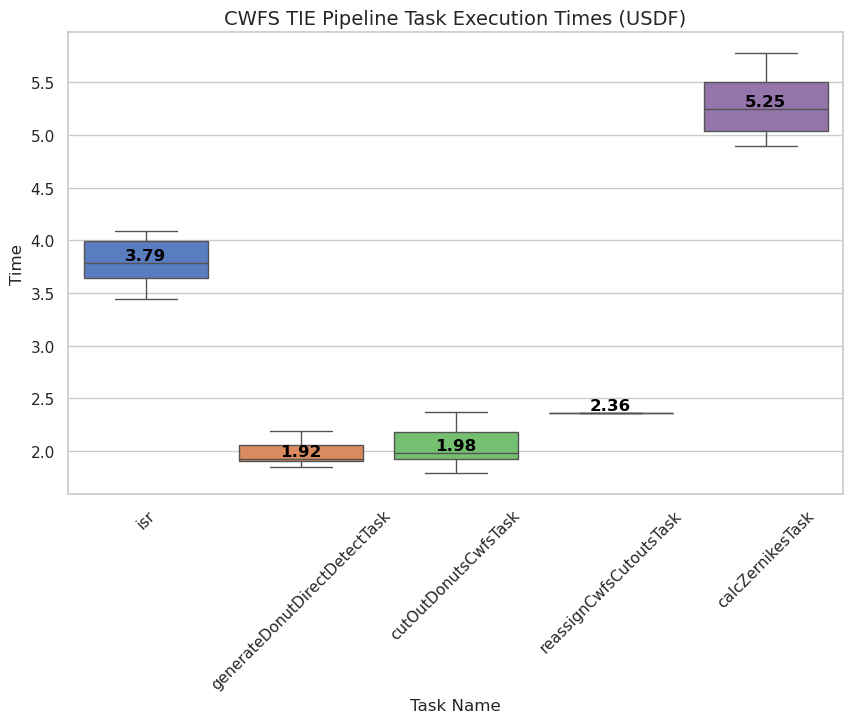

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#Sample data (replace with your actual DataFrame)
# df = pd.DataFrame({
#     'task_name': ['isr'] * 50 + ['calcZernikesTask'] * 50,
#     'time': [14.71, 14.55, 15.53, 14.55, 14.39, 8.34, 5.55, 7.34, 6.37, 6.98]*10
# })

# Set the plot style
sns.set(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='task_name', y='time', data=df, showfliers=False, palette="muted")

# Customize labels and title
plt.xlabel('Task Name', fontsize=12)
plt.ylabel('Time', fontsize=12)
plt.title('CWFS TIE Pipeline Task Execution Times (USDF)', fontsize=14)
# ax.yaxis.grid(False)
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

# Calculate medians for each task
medians = df.groupby('task_name')['time'].median()
print(medians)
for i, task in enumerate(task_list):
    median_value = medians[task]
    ax.text(i, median_value, f'{median_value:.2f}', 
            horizontalalignment='center', 
            verticalalignment='bottom', 
            fontsize=12, fontweight='bold', color='black')

# Show the plot
plt.xticks(rotation=45)  # Rotate task names if necessary
plt.show()

In [83]:
postISRCCD = butler.get('postISRCCD', dataId={'instrument': 'LSSTCam', 'detector': 203, 'exposure': 5024072302001,}, collections=collection_name)

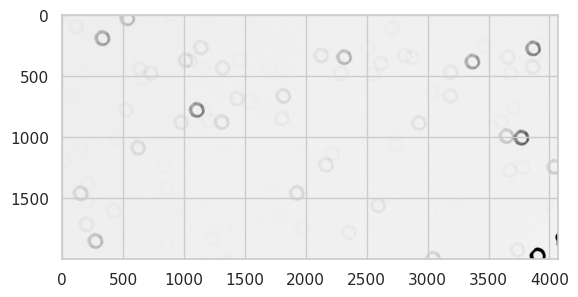

In [90]:
plt.imshow(postISRCCD.image.array, vmax=1000, cmap=plt.colormaps.get('Greys'))

In [36]:
df

,task_name,time
0,isr,260.017118
1,isr,5.495560
2,isr,18.664260
3,isr,4.972742
4,isr,64.902444
5,isr,5.501851
6,isr,9.938890
7,isr,5.625738
0,generateDonutDirectDetectTask,1.698224
1,generateDonutDirectDetectTask,1.903824


task_name
calcZernikesTask                 8.440080
cutOutDonutsCwfsTask             1.948682
generateDonutDirectDetectTask    1.906924
isr                              7.782314
reassignCwfsCutoutsTask          2.340335
Name: time, dtype: float64


/tmp/ipykernel_6476/2887833297.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='task_name', y='time', data=df_new, showfliers=False, palette="muted")


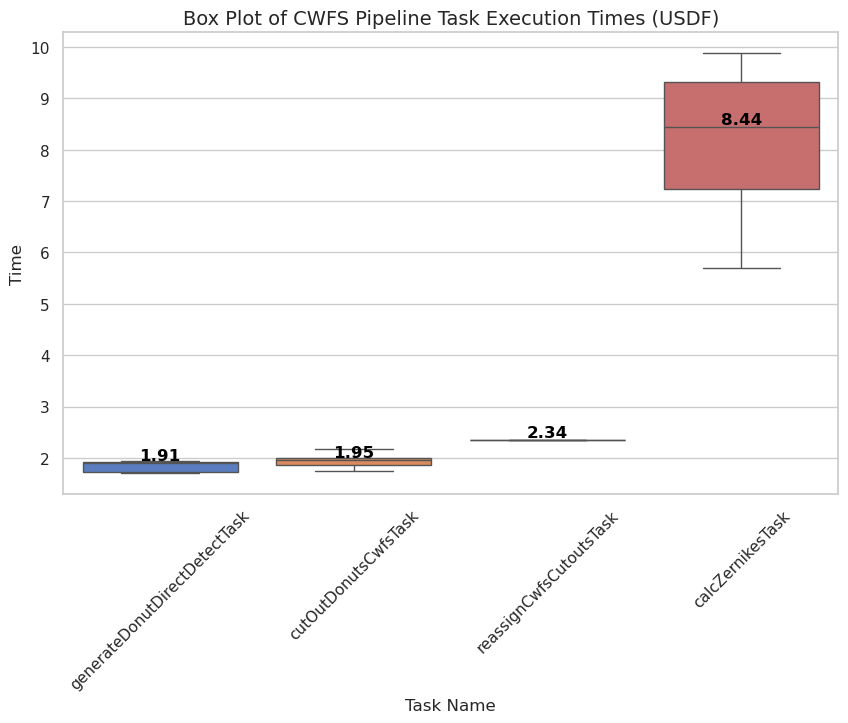

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

#Sample data (replace with your actual DataFrame)
# df = pd.DataFrame({
#     'task_name': ['isr'] * 50 + ['calcZernikesTask'] * 50,
#     'time': [14.71, 14.55, 15.53, 14.55, 14.39, 8.34, 5.55, 7.34, 6.37, 6.98]*10
# })

# Set the plot style
sns.set(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
df_new = df.iloc[8:]
ax = sns.boxplot(x='task_name', y='time', data=df_new, showfliers=False, palette="muted")

# Customize labels and title
plt.xlabel('Task Name', fontsize=12)
plt.ylabel('Time', fontsize=12)
plt.title('Box Plot of CWFS Pipeline Task Execution Times (USDF)', fontsize=14)
# ax.yaxis.grid(False)
# ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))

# Calculate medians for each task
medians = df.groupby('task_name')['time'].median()
print(medians)
for i, task in enumerate(task_list[1:]):
    median_value = medians[task]
    ax.text(i, median_value, f'{median_value:.2f}', 
            horizontalalignment='center', 
            verticalalignment='bottom', 
            fontsize=12, fontweight='bold', color='black')

# Show the plot
plt.xticks(rotation=45)  # Rotate task names if necessary
plt.show()

<Axes: xlabel='time', ylabel='Count'>

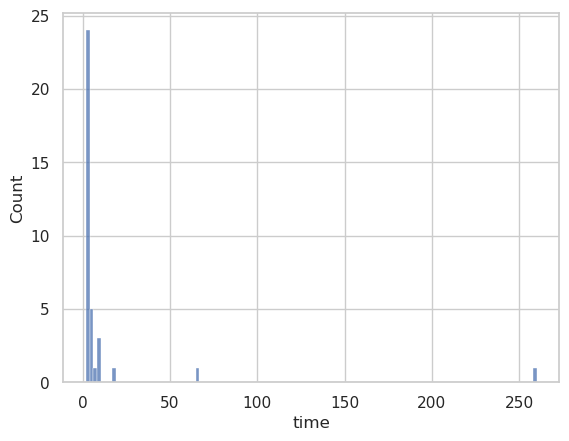

In [30]:
sbs.histplot(df, x='time')

<Axes: xlabel='time', ylabel='task_name'>

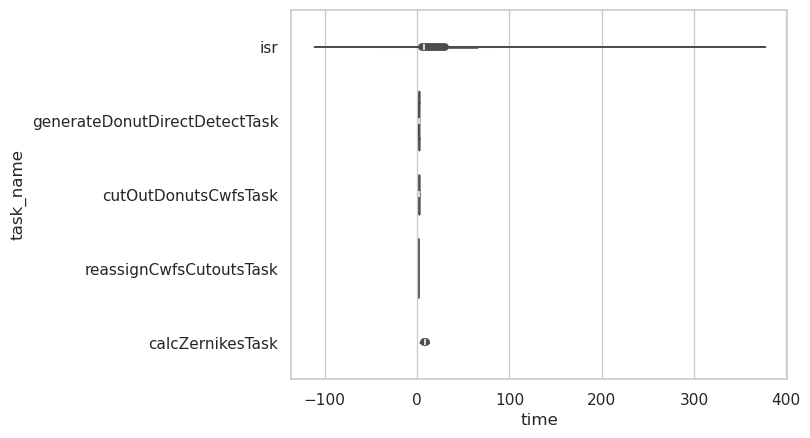

In [31]:
sbs.violinplot(df.iloc[:1000], x='time', y='task_name')

5024072302004 5024072302004 191 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 192 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 195 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 196 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 199 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 200 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 203 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 204 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 191 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 192 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 195 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 196 LSSTCam u/brycek/updated_timing_test_cwfs_danish
5024072302004 5024072302004 

KeyError: 'cutOutDonutsCwfsTask'

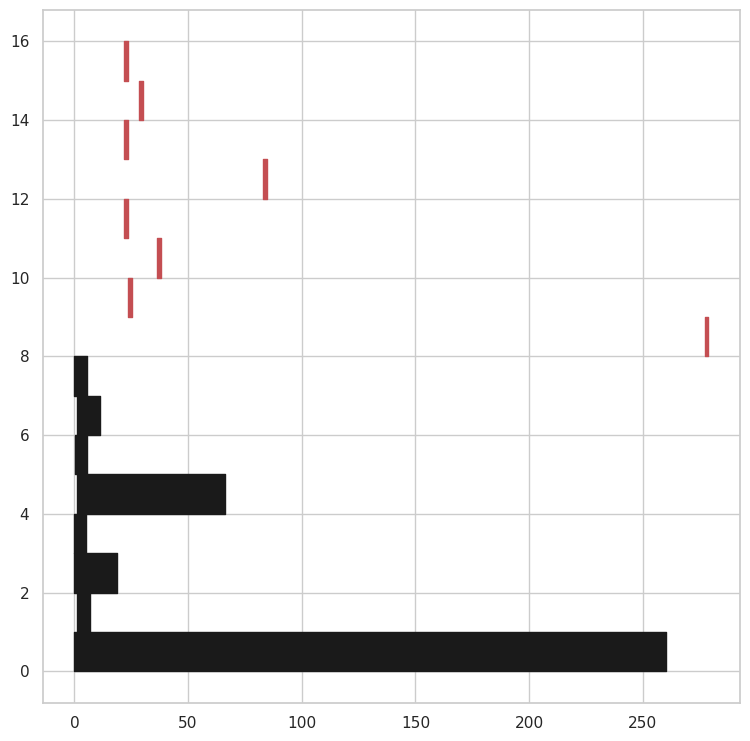

In [32]:
from matplotlib.lines import Line2D
task_metadata = get_task_metadata(butler_path, collection_name, instrument, task_list, exposure_list, group_list, detector_list)
jobs, first_job, last_job, longest_job_5_donuts = get_timing_from_metadata(task_metadata)
t0 = Time(min(j[1] for j in jobs)[:-6]).mjd

# Plot
plt.figure(figsize=(9,9))

start_list = []
ijob = -1
for job in jobs:
    start = (Time(job[1][:-6]).mjd-t0) * 86400
    end = (Time(job[2][:-6]).mjd-t0) * 86400
    if start in start_list:
        continue
    else:
        start_list.append(start)
        ijob += 1
    plt.fill_between([start, end], ijob, ijob+1, color=colors[job[0]])

# Create custom legend elements for both patches and lines
legend_elements = []
for k, v in colors.items():
    legend_elements.append(
        Patch(facecolor=v, label=k)
    )
# Add line elements to legend
legend_elements.append(Line2D([0], [0], color='C0', label='Task started'))
legend_elements.append(Line2D([0], [0], color='r', label='Task finished'))

# Calculate time between tasks
plt.axvline(0, color='C0')
plt.axvline((Time(last_job[-1][:-6]).mjd-t0) * 86400, color='r')
for first, last in zip(first_job[1:], last_job[:-1]):
    start = (Time(first[:-6]).mjd-t0) * 86400
    end = (Time(last[:-6]).mjd-t0) * 86400
    plt.axvline(start, color='C0')
    plt.axvline(end, color='r')
    #plt.text(end, 0.5, f'{(start-end):.2f}s', size=16, weight='bold')
    
# Add the legend to the plot
plt.legend(handles=legend_elements,)
plt.xlabel("Time (s)")
plt.ylabel("Job #")
plt.title('AOS Pipeline on one pair of ComCam visits (9 det*2 exp=18 raws, run w/ 9 processes).')
plt.tight_layout()

In [ ]:
fig = plt.figure()
t_start = 0
i = 0
for job_time, task in zip(longest_job_5_donuts, task_list):
    plt.fill_between([t_start, t_start+job_time], i, i+1, color=colors[task], label=task)
    t_start += job_time
    plt.text(t_start + 0.1, i+0.5, f"Max Time:\n {job_time:.2f}s")
    i += 1
plt.yticks([0.5, 1.5, 2.5, 3.5], ['ISR', 'Catalog\nCreation', 'Stamp\nGeneration', 'Zernike\nEstimation\n(5 Sources)'], size=9)
plt.legend()
plt.xlabel('Time (sec)')
plt.title('Expected Maximum Runtime per Task Type')

In [16]:
# with open('comcam_onsky_timing.pickle', 'wb') as handle:
#     pickle.dump(full_timing_dict, handle)